# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from cross_sections import *
%matplotlib inline
pd.set_option('display.max_rows', 20 )

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\exp1000\00_LP30_pristine"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [3]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2022\PSI22_04NI\Raw_images\exp2000\exp2200_LP40_deg\02_pos00\IMAT00018918_02_pos00_001_Spectra.txt"

#### Provide the directory for saving results

In [4]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\02_Cross_sections_results\exp1000\00_LP30_pristine"

### Read the directory and extract values from images
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [5]:
stack_dict = read_saved_dict (src_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:01<00:00,  4.33it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [6]:
avg_imgs = []
for key, value in stack_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_slice = 3, end_slice = 30)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [7]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')
ROIs_02_pos00 = [[111, 92, 329, 82], [97, 73, 78, 378], [95, 342, 353, 78], [346, 83, 75, 356]]
ROIs_04_pos01 = [[111, 92, 329, 82], [97, 73, 78, 321], [95, 342, 353, 65], [346, 83, 75, 313]]
ROIs_06_pos02 = [[83, 92, 347, 82], [97, 84, 78, 349], [84, 337, 353, 66], [339, 83, 84, 321]]
ROIs_08_pos03 = [[83, 92, 347, 82], [97, 84, 78, 349], [84, 337, 353, 66], [339, 83, 84, 321]]
ROIs_10_pos04 = [[83, 92, 347, 82], [97, 84, 78, 349], [84, 337, 353, 66], [339, 83, 84, 321]]

# degrad LP30
#ROIs_04_pos01 = [[111, 92, 329, 82], [97, 73, 78, 312], [95, 342, 353, 52], [346, 83, 75, 308]]
#ROIs_06_pos02 = [[83, 92, 347, 82], [97, 73, 78, 213], [286, 327, 172, 86], [339, 83, 84, 321]]
#ROIs_08_pos03 = [[333, 33, 102, 95], [97, 106, 78, 345], [84, 337, 353, 66], [346, 273, 75, 187]]
#ROIs_10_pos04 = [[83, 92, 347, 82], [97, 84, 78, 349], [84, 337, 353, 66], [339, 213, 75, 267]]

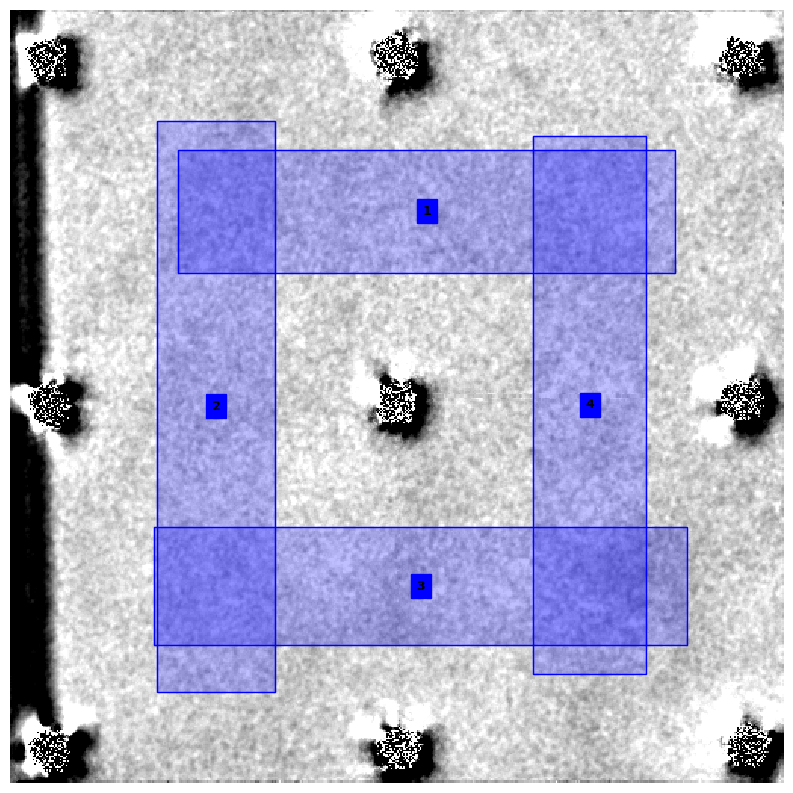

In [8]:
show_img(avg_imgs[0], dr = [(ROIs_02_pos00, 'blue')], cmap='gray')

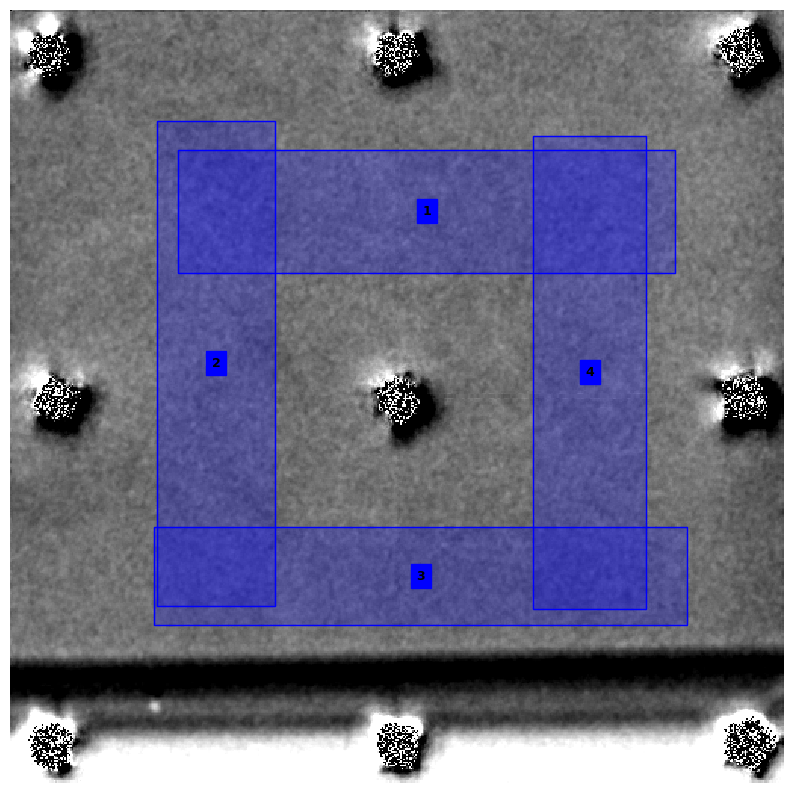

In [9]:
show_img(avg_imgs[1], dr = [(ROIs_04_pos01, 'blue')], cmap='gray')

#### Create a dictionary of the ROIs

In [10]:
rois_dict = {}
for name in stack_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [11]:
table_val_rois = get_roi_values (stack_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56.5, start_slice = 0, end_slice='', name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [12]:
table_val_rois = table_val_rois.loc[1: 36]
table_val_rois = table_val_rois.reset_index(drop=True)
table_val_rois

,Wavelength [Å],Values_02_pos00_roi_1,Values_02_pos00_roi_2,Values_02_pos00_roi_3,Values_02_pos00_roi_4,Values_04_pos01_roi_1,Values_04_pos01_roi_2,Values_04_pos01_roi_3,Values_04_pos01_roi_4,Values_06_pos02_roi_1,...,Values_06_pos02_roi_3,Values_06_pos02_roi_4,Values_08_pos03_roi_1,Values_08_pos03_roi_2,Values_08_pos03_roi_3,Values_08_pos03_roi_4,Values_10_pos04_roi_1,Values_10_pos04_roi_2,Values_10_pos04_roi_3,Values_10_pos04_roi_4
0,1.038601,0.908162,0.904179,0.898527,0.905625,0.893912,0.890408,0.903017,0.901119,0.891204,...,0.915213,0.898810,0.897491,0.900659,0.903925,0.911105,0.910544,0.926264,0.909270,0.899924
1,1.268037,0.883682,0.878205,0.876714,0.882191,0.885568,0.885863,0.882245,0.884578,0.885708,...,0.884096,0.888092,0.883359,0.883672,0.881436,0.881225,0.887428,0.890550,0.891252,0.892889
2,1.518394,0.869209,0.872138,0.871088,0.871511,0.875994,0.873931,0.872871,0.875620,0.873700,...,0.874541,0.874793,0.874423,0.871728,0.874598,0.873641,0.878686,0.880807,0.881957,0.880025
3,1.760742,0.861261,0.862814,0.860633,0.860885,0.864091,0.864271,0.864513,0.864920,0.862862,...,0.864972,0.862399,0.863475,0.865026,0.865117,0.863555,0.870382,0.870191,0.872349,0.869281
4,2.014248,0.854202,0.855790,0.853398,0.853705,0.859858,0.859250,0.856095,0.859366,0.853887,...,0.858705,0.857257,0.854632,0.855903,0.857426,0.856375,0.861896,0.863924,0.864503,0.863048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,8.728187,0.747423,0.737630,0.742791,0.744851,0.756671,0.744294,0.732920,0.753254,0.766723,...,0.764486,0.765692,0.753876,0.743386,0.755536,0.764602,0.751678,0.758088,0.755786,0.754229
32,8.959955,0.767913,0.750133,0.744841,0.757133,0.776030,0.758799,0.744954,0.765140,0.751807,...,0.753853,0.756481,0.743271,0.729066,0.745500,0.754914,0.754916,0.764547,0.761017,0.751873
33,9.189391,0.751749,0.742084,0.756595,0.759494,0.781065,0.758821,0.738986,0.766146,0.759876,...,0.756236,0.760507,0.752777,0.740196,0.759753,0.770901,0.765023,0.769372,0.760429,0.764422
34,9.441009,0.757330,0.743856,0.755582,0.759405,0.756992,0.751541,0.736463,0.757250,0.748455,...,0.749001,0.746579,0.755383,0.731859,0.741978,0.759291,0.767422,0.761398,0.765953,0.770139


### H cross section parameters

In [16]:
thickness = 0.058
#h2o = {'abbv': 'H2O','composition' : {'H':2.0, 'O':1.0},'density':0.997, 'thickness': thickness}
ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dmc_11w = {'abbv': 'EC_DMC (1:1w)','molecules' : [ec,0.447511501,dmc,0.552488499], 'density':1.2335, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#ec_dec_37w = {'abbv': 'EC_DEC (3:7w)','molecules' : [ec,0.240305619,dec,0.759694381], 'density':1.0705, 'thickness': thickness}
lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}
#lp47 = {'abbv': 'LP47','molecules' : [ec, 0.218207723,dec, 0.689834809, lipf6 ,0.091957467], 'density':1.1685, 'thickness': thickness}
#ec_dec_sol = {'abbv': 'EC_DEC (sol)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#pe = {'abbv': 'PE', 'composition' : {'C':1.0, 'H':2.0},'density':0.92, 'thickness': thickness}

## exp1000 -> LP30


In [17]:
compounds_dict = [lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [18]:
requested_cs = ['h_cs']
cs_table = get_cross_sections (table_val_rois, compounds_dict, requested_cs, dst_dir = src_dir, save_table = False, 
                               name_xlsx = 'test.xlsx')

In [19]:
cs_table

,Wavelength [Å],CS_H_in_LP30_Values_02_pos00_roi_1,CS_H_in_LP30_Values_02_pos00_roi_2,CS_H_in_LP30_Values_02_pos00_roi_3,CS_H_in_LP30_Values_02_pos00_roi_4,CS_H_in_LP30_Values_04_pos01_roi_1,CS_H_in_LP30_Values_04_pos01_roi_2,CS_H_in_LP30_Values_04_pos01_roi_3,CS_H_in_LP30_Values_04_pos01_roi_4,CS_H_in_LP30_Values_06_pos02_roi_1,...,CS_H_in_LP30_Values_06_pos02_roi_3,CS_H_in_LP30_Values_06_pos02_roi_4,CS_H_in_LP30_Values_08_pos03_roi_1,CS_H_in_LP30_Values_08_pos03_roi_2,CS_H_in_LP30_Values_08_pos03_roi_3,CS_H_in_LP30_Values_08_pos03_roi_4,CS_H_in_LP30_Values_10_pos04_roi_1,CS_H_in_LP30_Values_10_pos04_roi_2,CS_H_in_LP30_Values_10_pos04_roi_3,CS_H_in_LP30_Values_10_pos04_roi_4
0,1.038601,39.644550,41.737935,44.723935,40.976581,47.175996,49.046457,42.349881,43.351878,48.620955,...,35.961398,44.573729,45.273138,43.595029,41.871336,38.103611,38.396954,30.246027,39.063739,43.984013
1,1.268037,52.486173,55.446903,56.255726,53.290059,51.471000,51.312327,53.261055,52.003252,51.395318,...,52.262837,50.115455,52.660157,52.491551,53.697994,53.812018,50.471387,48.799053,48.424250,47.550218
2,1.518394,60.155752,58.553514,59.127490,58.895973,56.452970,57.575455,58.153351,56.656392,57.701379,...,57.243181,57.106041,57.307686,58.777333,57.212079,57.733923,54.991879,53.843570,53.222192,54.266704
3,1.760742,64.334293,63.476760,64.682079,64.542735,62.772492,62.673056,62.539997,62.315852,63.449917,...,62.286910,63.705926,63.111972,62.257416,62.207180,63.068046,59.317820,59.422510,58.242617,59.920830
4,2.014248,68.040987,67.156680,68.489899,68.318427,64.898372,65.235058,66.987039,65.170825,68.217122,...,65.537565,66.341240,67.801805,67.094145,66.247354,66.831153,63.771236,62.651808,62.332931,63.134945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,8.728187,123.695974,129.977012,126.656311,125.337310,117.839751,125.693742,133.026957,119.995313,111.555479,...,112.946717,112.196073,119.602504,126.275170,118.554878,112.874759,120.992646,116.949053,118.397528,119.379570
32,8.959955,110.497302,121.652382,125.024154,117.229105,105.489713,116.182471,124.951516,112.219588,120.591398,...,119.296582,117.639942,126.028946,135.217767,124.602874,118.626889,118.626047,112.588797,114.792901,120.549438
33,9.189391,120.305747,126.468379,117.246005,115.425118,102.088347,115.846923,128.460168,111.271825,115.185063,...,117.471772,114.790387,119.655451,127.681336,115.262730,108.325472,111.970511,109.271199,114.838764,112.344924
34,9.441009,116.434077,124.982517,117.534043,115.131037,116.646764,120.088041,129.739102,116.484292,122.047727,...,121.700331,123.242686,117.659568,132.725544,126.186200,115.202396,110.130011,113.883096,111.042401,108.446819


In [20]:
cs_ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI"
cs_ref_data = pd.read_csv (cs_ref_dir + '\cs_ref_IMAT20_bin2.txt',sep='\t')
cs_ref_data = cs_ref_data.loc[1:36, ['target wvl','target cs LP30', 'target cs PE']]
cs_ref_data = cs_ref_data.reset_index(drop=True)
cs_ref_data

,target wvl,target cs LP30,target cs PE
0,1.039,44.462956,41.106100
1,1.268,49.396820,46.758279
2,1.519,55.337149,53.700464
3,1.761,59.383640,57.621745
4,2.015,64.454696,62.497845
...,...,...,...
31,8.730,131.988217,110.654097
32,8.962,133.570808,111.285346
33,9.192,135.137477,111.910245
34,9.443,136.855612,112.595559


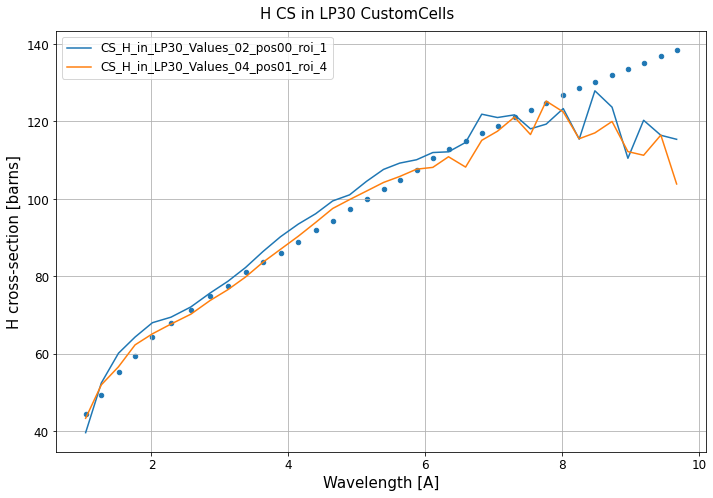

In [21]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table.plot(x='Wavelength [Å]', y=['CS_H_in_LP30_Values_02_pos00_roi_1', 'CS_H_in_LP30_Values_04_pos01_roi_4'])
cs_ref_data.plot(ax = ax, x='target wvl', y=['target cs LP30'], 
                 grid = True, fontsize = 12, kind = 'scatter')

plt.suptitle('H CS in LP30 CustomCells', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("H cross-section [barns]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

### Normalize to 3A

In [22]:
cs_table_norm3A = normalize_3A (cs_table)

In [23]:
cs_ref_norm3A = normalize_3A (cs_ref_data, 'target wvl')

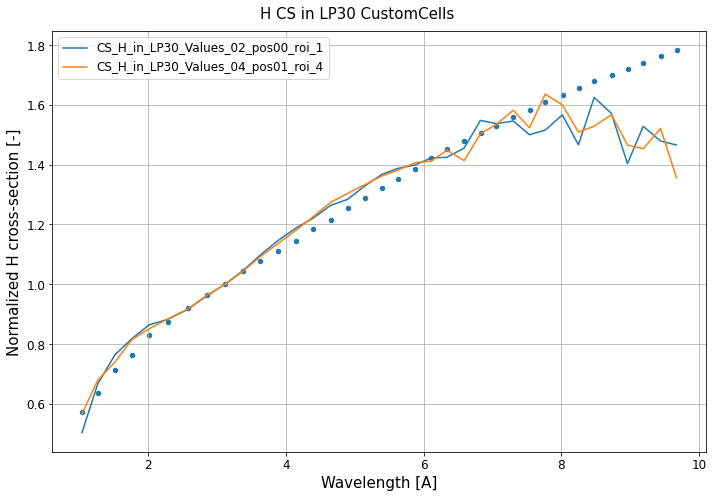

In [24]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table_norm3A.plot(x='Wavelength [Å]', y=['CS_H_in_LP30_Values_02_pos00_roi_1', 'CS_H_in_LP30_Values_04_pos01_roi_4'])
cs_ref_norm3A.plot(ax = ax, x='target wvl', y=['target cs LP30'], 
                 grid = True, fontsize = 12, kind = 'scatter')

plt.suptitle('H CS in LP30 CustomCells', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("Normalized H cross-section [-]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()

### Normalize by PE and 3A
The values listed are interpolated to match the wavelength of the experiment CS

In [25]:
PE_list_vals = cs_ref_norm3A['target cs PE']. to_list()
cs_table_norm3A_PE = normalize_3A_PE (cs_table_norm3A, PE_list_vals)
cs_ref_norm3A_PE = normalize_3A_PE (cs_ref_norm3A, PE_list_vals, 'target wvl')
cs_table_norm3A_PE

,Wavelength [Å],CS_H_in_LP30_Values_02_pos00_roi_1,CS_H_in_LP30_Values_02_pos00_roi_2,CS_H_in_LP30_Values_02_pos00_roi_3,CS_H_in_LP30_Values_02_pos00_roi_4,CS_H_in_LP30_Values_04_pos01_roi_1,CS_H_in_LP30_Values_04_pos01_roi_2,CS_H_in_LP30_Values_04_pos01_roi_3,CS_H_in_LP30_Values_04_pos01_roi_4,CS_H_in_LP30_Values_06_pos02_roi_1,...,CS_H_in_LP30_Values_06_pos02_roi_3,CS_H_in_LP30_Values_06_pos02_roi_4,CS_H_in_LP30_Values_08_pos03_roi_1,CS_H_in_LP30_Values_08_pos03_roi_2,CS_H_in_LP30_Values_08_pos03_roi_3,CS_H_in_LP30_Values_08_pos03_roi_4,CS_H_in_LP30_Values_10_pos04_roi_1,CS_H_in_LP30_Values_10_pos04_roi_2,CS_H_in_LP30_Values_10_pos04_roi_3,CS_H_in_LP30_Values_10_pos04_roi_4
0,1.038601,0.924986,0.987591,1.032903,0.951391,1.138913,1.162111,0.994224,1.040002,1.108932,...,0.840177,1.040544,1.034884,0.997633,0.973966,0.890930,0.906699,0.723575,0.943445,1.050349
1,1.268037,1.076575,1.153377,1.142179,1.087721,1.092396,1.068832,1.099233,1.096742,1.030511,...,1.073433,1.028492,1.058233,1.056017,1.098077,1.106125,1.047754,1.026300,1.028142,0.998250
2,1.518394,1.074378,1.060541,1.045291,1.046736,1.043241,1.044253,1.045045,1.040407,1.007386,...,1.023732,1.020450,1.002749,1.029608,1.018692,1.033324,0.994015,0.986000,0.983929,0.991975
3,1.760742,1.070814,1.071472,1.065672,1.069032,1.081083,1.059353,1.047393,1.066460,1.032363,...,1.038128,1.060916,1.029160,1.016353,1.032256,1.051978,0.999243,1.014112,1.003468,1.020790
4,2.014248,1.044151,1.045145,1.040369,1.043284,1.030492,1.016628,1.034342,1.028302,1.023331,...,1.007084,1.018606,1.019374,1.009856,1.013531,1.027774,0.990449,0.985802,0.990151,0.991631
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,8.728187,1.072126,1.142487,1.086639,1.081042,1.056818,1.106350,1.160140,1.069373,0.945173,...,0.980272,0.972967,1.015618,1.073471,1.024437,0.980422,1.061363,1.039323,1.062243,1.059029
32,8.959955,0.952295,1.063249,1.066552,1.005373,0.940693,1.016831,1.083532,0.994405,1.015935,...,1.029510,1.014389,1.064118,1.142973,1.070591,1.024540,1.034700,0.994898,1.024061,1.063341
33,9.189391,1.031038,1.099169,0.994613,0.984374,0.905279,1.008233,1.107738,0.980501,0.964970,...,1.008101,0.984291,1.004662,1.073242,0.984810,0.930346,0.971195,0.960190,1.018750,0.985437
34,9.441009,0.991783,1.079644,0.990988,0.975890,1.028081,1.038783,1.111957,1.020184,1.016240,...,1.038033,1.050334,0.981892,1.108851,1.071578,0.983386,0.949417,0.994625,0.979076,0.945455


In [26]:
cs_ref_norm3A_PE

,target wvl,target cs LP30,target cs PE
0,1.039,1.052072,1.0
1,1.268,1.027528,1.0
2,1.519,1.002287,1.0
3,1.761,1.002383,1.0
4,2.015,1.003097,1.0
...,...,...,...
31,8.730,1.160168,1.0
32,8.962,1.167419,1.0
33,9.192,1.174517,1.0
34,9.443,1.182210,1.0


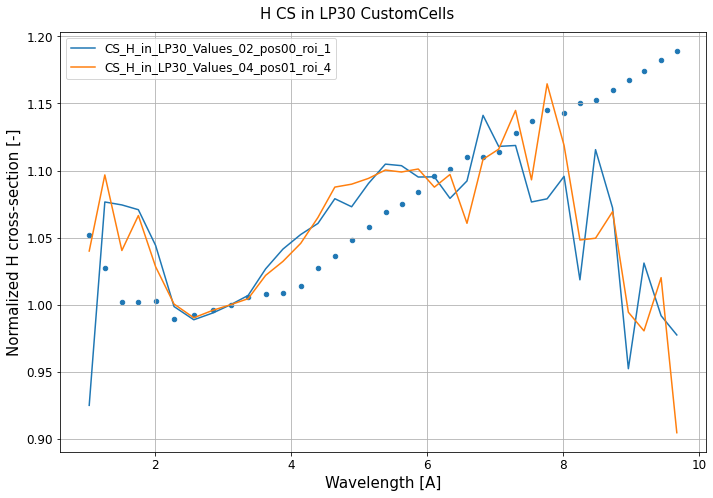

In [28]:
plt.rcParams["figure.figsize"] = [10.0, 7.0]
plt.rcParams["figure.autolayout"] = True

ax = cs_table_norm3A_PE.plot(x='Wavelength [Å]', y=['CS_H_in_LP30_Values_02_pos00_roi_1', 'CS_H_in_LP30_Values_04_pos01_roi_4'])
cs_ref_norm3A_PE.plot(ax = ax, x='target wvl', y=['target cs LP30'], 
                 grid = True, fontsize = 12, kind = 'scatter')

plt.suptitle('H CS in LP30 CustomCells', fontsize=15)
ax.set_xlabel("Wavelength [A]")
ax.set_ylabel("Normalized H cross-section [-]")
ax.legend(fontsize=12)
ax.xaxis.label.set_size(15)
ax.yaxis.label.set_size(15)
plt.show()